# Brace-Height Method — Functional Analysis

This notebook exercises the **brace-height** PIC estimator implemented in
`hdsemg_shared.motor_unit` (Beauchamp et al., 2023) on a *decomposed* HD-sEMG
recording.

**Pipeline**
1. **Load** a decomposed file with [`openhdemg`](https://www.giacomovalli.com/openhdemg/).
   Decomposition - here we use openhdemg's bundled sample decomposition.
2. **Inspect a MUAP** via spike-triggered averaging of the raw EMG.
3. **Discharge rate** → instantaneous rate (1/ISI) for a chosen motor unit.
4. **Smooth** the rate (Support Vector Regression).
5. **Brace height** + supplemental metrics (acceleration/attenuation slope, angle)


In [1]:
import sys
from pathlib import Path

# Make hdsemg_shared importable
_p = Path.cwd()
for _cand in [_p, *_p.parents]:
    if (_cand / "src" / "hdsemg_shared").exists():
        sys.path.insert(0, str(_cand / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openhdemg.library as emg

from hdsemg_shared.motor_unit import (
    firing_times_from_indices,
    instantaneous_discharge_rate,
    smooth_discharge_rate_svr,
    compute_brace_height,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 4.5)

## 1. Load a decomposed recording

`emg_from_samplefile()` returns openhdemg's bundled decomposition. To analyse
your **own** data, replace this with the appropriate loader, e.g.:

```python
emgfile = emg.emg_from_otb("my_decomposition.otb")          # OTBioLab+
emgfile = emg.emg_from_demuse("my_decomposition.mat")        # DEMUSE
emgfile = emg.askopenfile(filesource="OTB")                  # interactive picker
```

The key fields we use are `MUPULSES` (firing sample indices per MU),
`REF_SIGNAL` (force/torque), and `FSAMP` (sampling rate).

In [2]:
emgfile = emg.emg_from_samplefile()

FSAMP = float(emgfile["FSAMP"])
N_MU = int(emgfile["NUMBER_OF_MUS"])
ref_signal = emgfile["REF_SIGNAL"].iloc[:, 0].to_numpy(dtype=float)
ref_time = np.arange(ref_signal.size) / FSAMP

print(f"Source            : {emgfile['SOURCE']}")
print(f"Sampling rate     : {FSAMP:.0f} Hz")
print(f"Recording length  : {emgfile['EMG_LENGTH']} samples "
      f"({emgfile['EMG_LENGTH'] / FSAMP:.1f} s)")
print(f"Number of MUs     : {N_MU}")
for i, pulses in enumerate(emgfile["MUPULSES"]):
    print(f"  MU{i}: {len(pulses):3d} discharges")

Source            : OTB
Sampling rate     : 2048 Hz
Recording length  : 66560 samples (32.5 s)
Number of MUs     : 5
  MU0: 137 discharges
  MU1: 154 discharges
  MU2: 197 discharges
  MU3: 293 discharges
  MU4: 292 discharges


### Decomposition overview

The reference force/torque with each motor unit's firing instants (the
decomposition output) as a raster.

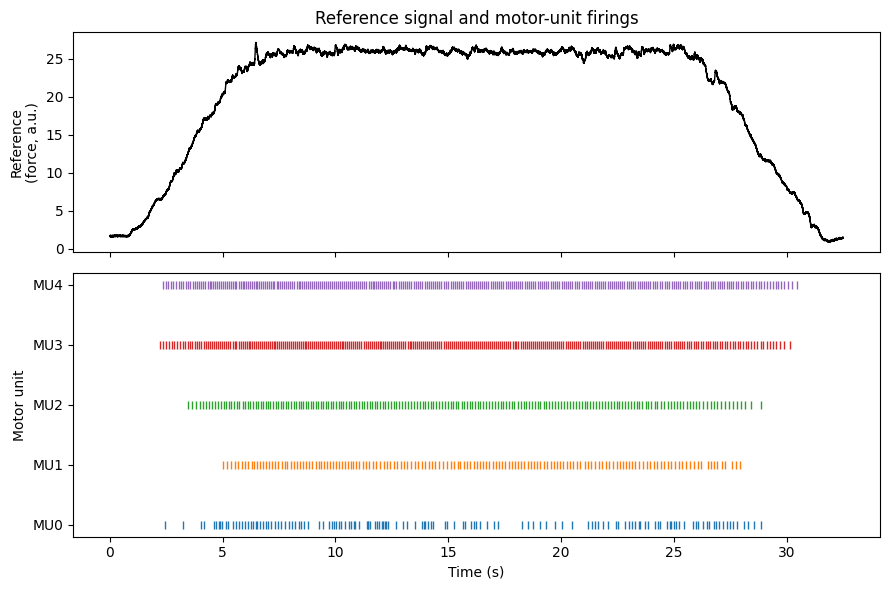

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 6),
                               gridspec_kw={"height_ratios": [1, 1.2]})

ax1.plot(ref_time, ref_signal, color="k", lw=1)
ax1.set_ylabel("Reference\n(force, a.u.)")
ax1.set_title("Reference signal and motor-unit firings")

for i, pulses in enumerate(emgfile["MUPULSES"]):
    t = np.asarray(pulses) / FSAMP
    ax2.plot(t, np.full_like(t, i, dtype=float), "|", ms=6)
ax2.set_yticks(range(N_MU))
ax2.set_yticklabels([f"MU{i}" for i in range(N_MU)])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Motor unit")
plt.tight_layout()
plt.show()

## 2. Inspect a detected MUAP (spike-triggered average)

A motor unit is *detected* through its action potential. Below we recover the
MUAP of the selected unit by spike-triggered averaging of the raw EMG and pick
the channel with the largest peak-to-peak amplitude.

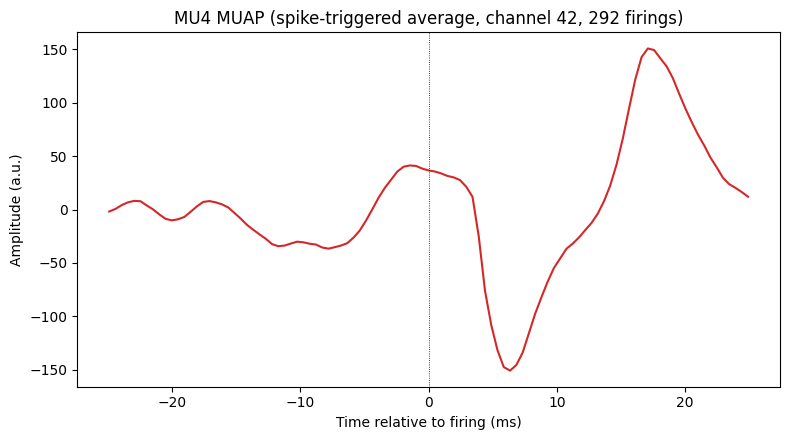

In [4]:
MU = 4   # <-- choose the motor unit to analyse

pulses = np.asarray(emgfile["MUPULSES"][MU])
raw = emgfile["RAW_SIGNAL"].to_numpy(dtype=float)   # (samples, channels)


def spike_triggered_average(raw, firings, fsamp, half_ms=25.0):
    'Average the raw EMG in a window around each firing -> MUAP per channel.'
    half = int(round(half_ms * 1e-3 * fsamp))
    valid = firings[(firings - half >= 0) & (firings + half < raw.shape[0])]
    idx = valid[:, None] + np.arange(-half, half + 1)[None, :]
    # raw[idx] -> (n_firings, win, channels); average over firings
    sta = raw[idx].mean(axis=0)              # (win, channels)
    lag = np.arange(-half, half + 1) / fsamp * 1e3   # ms
    return lag, sta


lag, sta = spike_triggered_average(raw, pulses, FSAMP)
best_ch = int(np.argmax(np.ptp(sta, axis=0)))

plt.figure()
plt.plot(lag, sta[:, best_ch], color="C3")
plt.axvline(0, color="k", lw=0.6, ls=":")
plt.title(f"MU{MU} MUAP (spike-triggered average, channel {best_ch}, "
          f"{len(pulses)} firings)")
plt.xlabel("Time relative to firing (ms)")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

## 3. Instantaneous discharge rate

The instantaneous discharge rate is the reciprocal of each inter-spike interval,
assigned to the later spike of the pair.

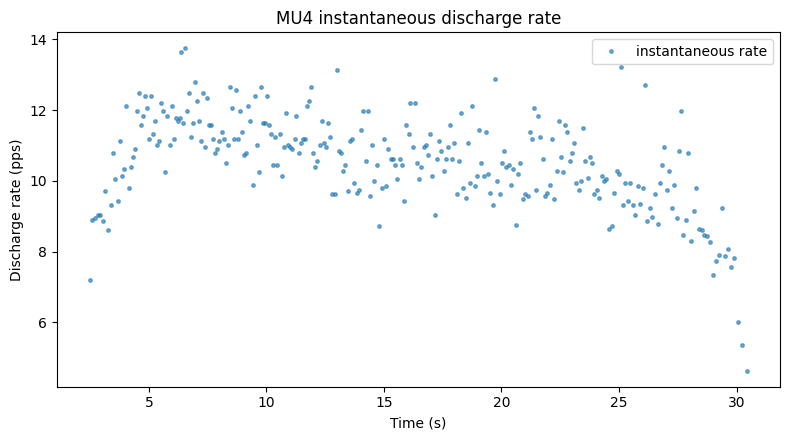

In [5]:
firing_times = firing_times_from_indices(pulses, FSAMP)
rate_times, rate = instantaneous_discharge_rate(firing_times)

plt.figure()
plt.plot(rate_times, rate, ".", ms=5, alpha=0.6, label="instantaneous rate")
plt.xlabel("Time (s)")
plt.ylabel("Discharge rate (pps)")
plt.title(f"MU{MU} instantaneous discharge rate")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Smooth the discharge rate (SVR)

Beauchamp et al. smooth the discharge rate with Support Vector Regression before
quantifying brace height. `smooth_discharge_rate_svr` reproduces this (it lazily
imports scikit-learn). Tune `C` / `gamma` for your data.

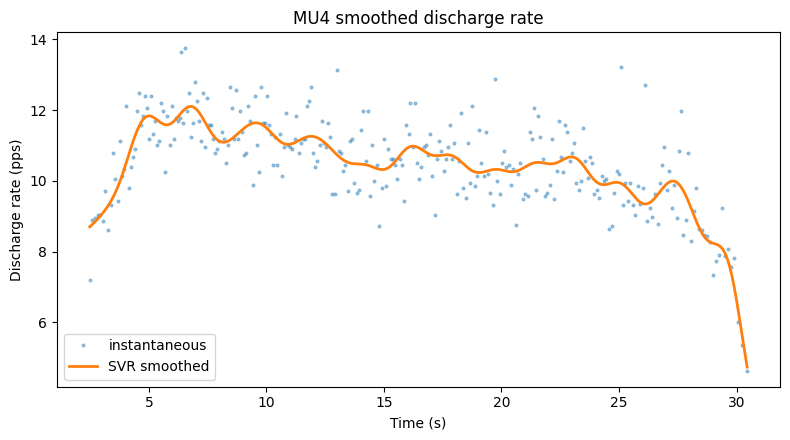

In [6]:
t_eval = np.linspace(rate_times[0], rate_times[-1], 300)
_, smooth_rate = smooth_discharge_rate_svr(rate_times, rate, t_eval, C=20.0, gamma=0.5)

# Reference force/torque resampled onto the MU's active window.
ref_window = np.interp(t_eval, ref_time, ref_signal)

plt.figure()
plt.plot(rate_times, rate, ".", ms=4, alpha=0.4, label="instantaneous")
plt.plot(t_eval, smooth_rate, "C1", lw=2, label="SVR smoothed")
plt.xlabel("Time (s)")
plt.ylabel("Discharge rate (pps)")
plt.title(f"MU{MU} smoothed discharge rate")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Brace height

`compute_brace_height` takes the smoothed discharge rate and the reference on the
same time base. It works from MU recruitment to **peak discharge rate**, fits the
straight "linear-discharge" hypotenuse, and finds the maximum deviation (the
brace point). Results are normalized to the right-triangle altitude (**% rTri**).

In [7]:
result = compute_brace_height(smooth_rate, ref_window)

print(f"MU{MU} brace-height metrics")
print(f"  brace height          : {result.brace_height_norm:6.2f} % rTri "
      f"({result.brace_height:.2f} pps vertical deviation)")
print(f"  acceleration slope    : {result.acceleration_slope:6.3f} pps / ref-unit")
print(f"  attenuation slope     : {result.attenuation_slope:6.3f} pps / ref-unit")
print(f"  angle                 : {result.angle:6.1f} deg")
print(f"  recruitment / brace / peak idx : "
      f"{result.recruitment_idx} / {result.brace_idx} / {result.peak_idx}")
print(f"  valid                 : {result.valid}  {result.exclusion_reasons}")

MU4 brace-height metrics
  brace height          :  23.84 % rTri (0.81 pps vertical deviation)
  acceleration slope    :  0.273 pps / ref-unit
  attenuation slope     :  0.074 pps / ref-unit
  angle                 :  191.1 deg
  recruitment / brace / peak idx : 0 / 23 / 46
  valid                 : True  []


### Brace-height geometry

Discharge rate plotted against the reference for the recruitment→peak segment,
with the linear-discharge hypotenuse, the brace point, the orthogonal brace
deviation, and the acceleration / attenuation phases.

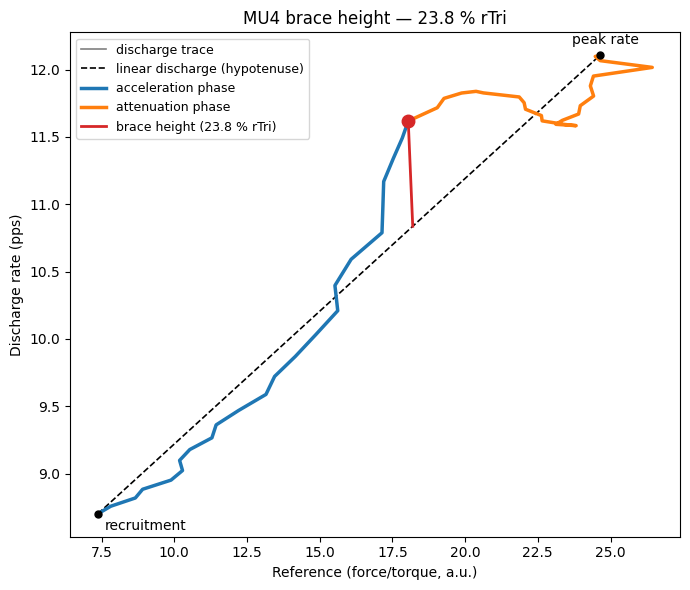

In [8]:
def plot_brace(result, title=""):
    x, y = result.x, result.y
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    bi = result.brace_idx - result.recruitment_idx
    xb, yb = x[bi], y[bi]

    # Foot of the perpendicular from the brace point onto the hypotenuse.
    d = np.array([x1 - x0, y1 - y0], float)
    t = np.dot([xb - x0, yb - y0], d) / np.dot(d, d)
    foot = np.array([x0, y0]) + t * d

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(x, y, color="0.5", lw=1.2, label="discharge trace")
    ax.plot([x0, x1], [y0, y1], "k--", lw=1.2, label="linear discharge (hypotenuse)")
    ax.plot(x[:bi + 1], y[:bi + 1], "C0", lw=2.5, label="acceleration phase")
    ax.plot(x[bi:], y[bi:], "C1", lw=2.5, label="attenuation phase")
    ax.plot([xb, foot[0]], [yb, foot[1]], "C3", lw=2,
            label=f"brace height ({result.brace_height_norm:.1f} % rTri)")
    ax.plot(xb, yb, "C3o", ms=9)
    ax.plot([x0, x1], [y0, y1], "k.", ms=10)
    ax.annotate("recruitment", (x0, y0), textcoords="offset points", xytext=(5, -12))
    ax.annotate("peak rate", (x1, y1), textcoords="offset points", xytext=(-20, 8))
    ax.set_xlabel("Reference (force/torque, a.u.)")
    ax.set_ylabel("Discharge rate (pps)")
    ax.set_title(title or f"Brace-height geometry  (angle {result.angle:.0f} deg)")
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()
    return ax


plot_brace(result, title=f"MU{MU} brace height — {result.brace_height_norm:.1f} % rTri")
plt.show()

## 6. All motor units

Run the full pipeline for every MU and tabulate the metrics. Units flagged by the
exclusion criteria (negative acceleration slope, > 200 % rTri, or peak discharge
after peak force) are marked `valid = False`.

In [9]:
rows = []
for mu in range(N_MU):
    p = np.asarray(emgfile["MUPULSES"][mu])
    try:
        ft = firing_times_from_indices(p, FSAMP)
        rt, rr = instantaneous_discharge_rate(ft)
        te = np.linspace(rt[0], rt[-1], 300)
        _, sm = smooth_discharge_rate_svr(rt, rr, te, C=20.0, gamma=0.5)
        rw = np.interp(te, ref_time, ref_signal)
        r = compute_brace_height(sm, rw)
        rows.append(dict(MU=mu, n_discharges=len(p),
                         brace_height_pct_rTri=round(r.brace_height_norm, 2),
                         acceleration_slope=round(r.acceleration_slope, 3),
                         attenuation_slope=round(r.attenuation_slope, 3),
                         angle_deg=round(r.angle, 1),
                         valid=r.valid,
                         exclusion="; ".join(r.exclusion_reasons)))
    except ValueError as exc:
        rows.append(dict(MU=mu, n_discharges=len(p), valid=False, exclusion=str(exc)))

summary = pd.DataFrame(rows)
summary

,MU,n_discharges,brace_height_pct_rTri,acceleration_slope,attenuation_slope,angle_deg,valid,exclusion
0,0,137,13.80,1.072,0.615,195.4,True,
1,1,154,18.28,0.599,0.100,205.2,False,peak discharge after peak force/torque
2,2,197,29.76,0.709,0.208,203.6,True,
3,3,293,23.32,0.387,0.129,193.8,True,
4,4,292,23.84,0.273,0.074,191.1,True,


## 7. Contraction consistency: performed vs. requested path

Brace height assumes a clean *triangular* ramp, so it is worth checking how well
the participant tracked the requested path (Ugliara et al., Suppl. Material 1).
The metric is the area between the **performed** torque and the **requested**
triangle (a linear rise to peak and a linear fall back to rest), split into
ascending and descending phases, in `%MVC·s`.

`contraction_consistency` / `plot_contraction_consistency` below work on any
reference trace. The demo reproduces the paper's figure on synthetic triangular
trials; the bundled sample recording is a *trapezoid* (plateau hold), not a
triangular task, so the same call on `ref_signal` would show large deviations by
construction.

In [10]:
_integrate = getattr(np, "trapezoid", np.trapz)   # NumPy 2.0 renamed trapz


def contraction_consistency(ref, fsamp, requested=None, onset_frac=0.05):
    """Area between a performed reference and the requested triangular path.

    If ``requested`` is None, the ideal triangle is built from the detected
    onset -> peak -> offset of ``ref``. Returns a dict with the requested path,
    the absolute difference, and ascending/descending/total areas (in ref-unit*s,
    e.g. %MVC*s).
    """
    ref = np.asarray(ref, dtype=float)
    peak_idx = int(np.argmax(ref if requested is None else requested))
    if requested is None:
        peak_val = ref[peak_idx]
        above = ref >= onset_frac * peak_val
        onset = int(np.argmax(above))
        offset = ref.size - 1 - int(np.argmax(above[::-1]))
        requested = np.zeros_like(ref)
        requested[onset:peak_idx + 1] = np.linspace(0, peak_val, peak_idx - onset + 1)
        requested[peak_idx:offset + 1] = np.linspace(peak_val, 0, offset - peak_idx + 1)
    else:
        requested = np.asarray(requested, dtype=float)
        nz = np.flatnonzero(requested > 1e-9)
        onset, offset = int(nz[0]), int(nz[-1])

    diff = np.abs(ref - requested)
    dx = 1.0 / fsamp
    asc = float(_integrate(diff[onset:peak_idx + 1], dx=dx))
    desc = float(_integrate(diff[peak_idx:offset + 1], dx=dx))
    return dict(t=np.arange(ref.size) / fsamp, requested=requested, diff=diff,
                onset=onset, peak_idx=peak_idx, offset=offset,
                ascending=asc, descending=desc, total=asc + desc)


def plot_contraction_consistency(ref, fsamp, requested=None, ax=None, title="",
                                 onset_frac=0.05):
    """Plot performed vs requested torque with the absolute-difference area."""
    r = contraction_consistency(ref, fsamp, requested=requested, onset_frac=onset_frac)
    t, pk = r["t"], r["peak_idx"]
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    ax.plot(t, ref, color="mediumorchid", lw=0.8, label="Performed")
    ax.plot(t, r["requested"], color="k", lw=2, label="Requested")
    ax.axvline(t[pk], color="0.4", ls="--", lw=1)
    ax.set_xlabel("time")
    ax.set_ylabel("Torque (%MVC)")
    ax.set_title(title)
    ax.set_ylim(0, np.nanmax(ref) * 1.15)

    ax2 = ax.twinx()  # absolute difference
    ax2.fill_between(t[:pk + 1], r["diff"][:pk + 1], color="steelblue", alpha=0.45)
    ax2.fill_between(t[pk:], r["diff"][pk:], color="firebrick", alpha=0.45)
    ax2.set_ylim(0, np.nanmax(r["diff"]) * 4 + 1e-6)
    ax2.set_ylabel("Absolute Difference (Req - Perf) (%MVC)")

    ax.text(0.97, 0.97,
            f"Total Area = {r['total']:.1f} %MVC·s\n"
            f"Ascending = {r['ascending']:.1f} %MVC·s\n"
            f"Descending = {r['descending']:.1f} %MVC·s",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="0.7"))
    return r

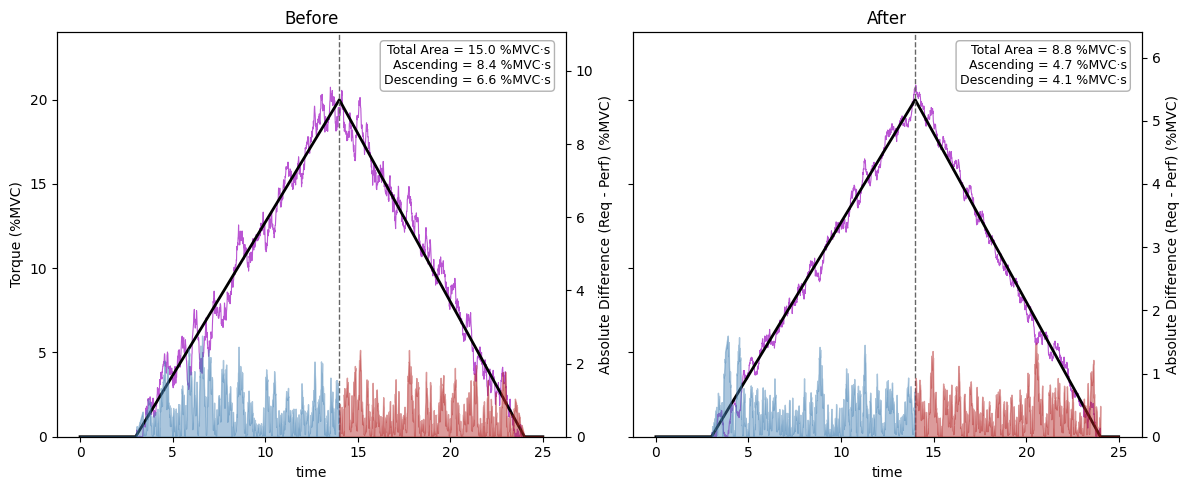

In [ ]:
# --- reproduce the Ugliara et al. 2025 (biorxiv)'s figure on synthetic triangular trials ---------
def _synthetic_triangle(peak=20.0, t_on=3.0, t_peak=14.0, t_off=24.0,
                        dur=25.0, fsamp=100.0, tremor=0.7, seed=0):
    """A noisy 'performed' triangular contraction and its ideal 'requested' path."""
    rng = np.random.default_rng(seed)
    t = np.arange(0, dur, 1 / fsamp)
    requested = np.zeros_like(t)
    up = (t >= t_on) & (t <= t_peak)
    dn = (t > t_peak) & (t <= t_off)
    requested[up] = np.interp(t[up], [t_on, t_peak], [0, peak])
    requested[dn] = np.interp(t[dn], [t_peak, t_off], [peak, 0])
    # physiological wiggle: smoothed noise, only while contracting
    k = int(0.3 * fsamp)
    wig = np.convolve(rng.normal(0, 1, t.size), np.ones(k) / k, mode="same")
    performed = requested + tremor * wig * (requested > 0)
    return t, np.clip(performed, 0, None), requested


# Two trials with different tracking quality, like the paper's Before/After.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (title, tremor, seed) in zip(
    axes, [("Before", 5.0, 1), ("After", 3.0, 4)]
):
    t, performed, requested = _synthetic_triangle(tremor=tremor, seed=seed, fsamp=100.0)
    plot_contraction_consistency(performed, fsamp=100.0, requested=requested,
                                 ax=ax, title=title)
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()